### [3강] 따릉이는 어디까지 닿고 있는가  
#### Folium 기반 따릉이 커버리지 시각화

3강에서는 2강에서 도출한 교통 비커버 지역을 바탕으로, **따릉이가 해당 지역들을 얼마나 보완적으로 커버하고 있는지**를 Folium 지도 위에서 직관적으로 확인한다.

이를 위해 본 강의에서는 GeoPandas로 전처리한 공간 데이터를 Folium으로 시각화하고,  
OSM 도로 네트워크를 활용한 **경로 계산 라이브러리**를 통해 따릉이 대여소를 중심으로 한 실제 이동 가능 범위를 함께 고려한다.

구체적으로는, OSMnx를 이용해 보행·자전거 도로 네트워크를 구성하고, NetworkX 기반 최단경로 알고리즘을 적용하여  
단순 직선 거리 대신 **현실적인 이동 경로 관점**에서 따릉이의 공간적 커버 구조를 해석한다.

행정경계, 비커버 폴리곤, 따릉이 대여소, 버스정류장, 지하철역을 하나의 인터랙티브 지도에 통합함으로써,  
따릉이가 교통 비커버 공간을 어느 정도 보완하고 있는지와 여전히 남아 있는 접근 사각지대를 시각적으로 파악하는 것이 본 강의의 핵심 목표이다.

본 강의는 지표 계산보다는 **공간 분포와 실제 이동 구조를 함께 이해하는 단계**로서, 이후 경로 기반 개선 시나리오 분석으로 확장하기 위한 기반을 제공한다.

- 서울시 따릉이 데이터 : https://data.seoul.go.kr/dataList/OA-21235/S/1/datasetView.do
- 버스정류장 위치정보 데이터 : https://data.seoul.go.kr/dataList/OA-15067/S/1/datasetView.do
- 지하철역 위치정보 데이터 : https://www.data.go.kr/data/15099316/fileData.do 
- 행정동 벡터 데이터 : https://www.vworld.kr/dtmk/dtmk_ntads_s002.do?svcCde=MK&dsId=30017

- Folium documentation : https://python-visualization.github.io/folium/latest/

In [1]:
%pip install osmnx

Note: you may need to restart the kernel to use updated packages.


#### OSMnx · NetworkX 기반 최단경로 알고리즘

**OSMnx**는 **OpenStreetMap(OSM)** 이 제공하는 전 세계 공개 도로 데이터를 기반으로,  
도로·보행로·자전거도로 네트워크를 **그래프 구조로 생성해주는 Python 라이브러리**이다.

**NetworkX**는 Python 기반의 **그래프 이론(Graph Theory) 분석 엔진**으로,  
OSMnx가 생성한 도로 그래프 위에서 **최단경로, 가중치 기반 거리 계산**을 수행한다.

두 라이브러리를 함께 사용하면 OpenStreetMap 도로 데이터를 활용해  
**직선거리가 아닌 실제 이동 가능한 도로 기준 최단경로**를 계산할 수 있다.

본 강의에서는 이를 적용해 따릉이 대여소에서 버스정류장·지하철역까지의  
**현실적인 보행 접근 경로를 지도 위에 시각화**한다.

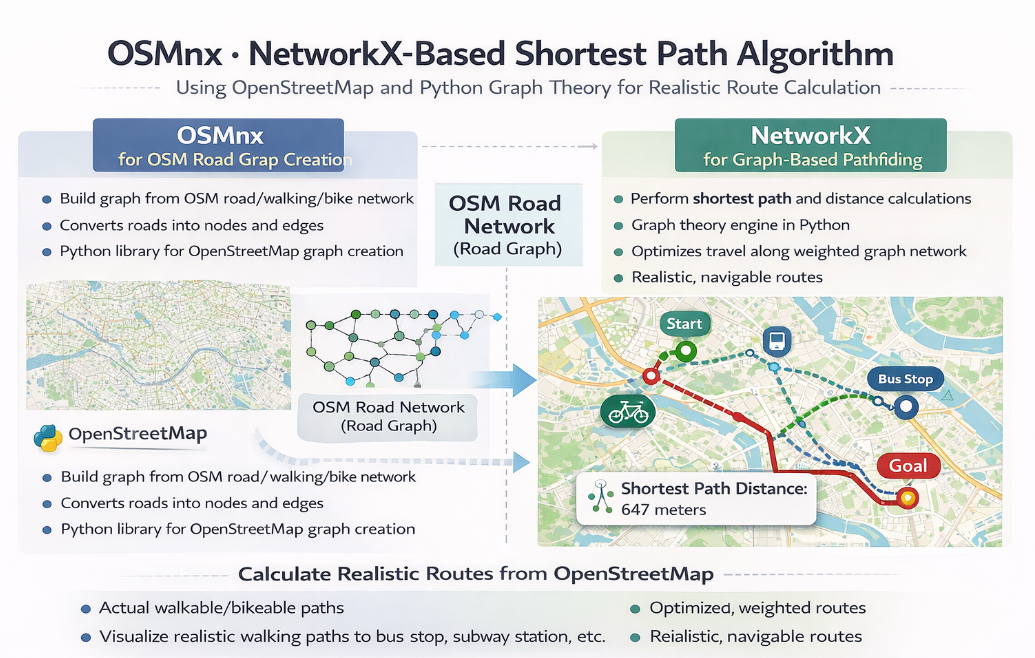

In [2]:
import os, warnings
warnings.filterwarnings("ignore")  
# os: 파일·경로 관리, warnings: 불필요한 경고 메시지 숨김

import pandas as pd
import numpy as np
# pandas: 표 형태 데이터 처리, numpy: 수치 연산 및 배열 처리

import geopandas as gpd
from shapely.geometry import LineString
from shapely.geometry import mapping
# geopandas: 공간 데이터프레임 처리
# LineString: 경로·선형 지오메트리 생성
# mapping: Shapely 지오메트리를 GeoJSON 형태로 변환

import folium
from folium.plugins import MarkerCluster
# folium: 웹 기반 인터랙티브 지도 시각화
# MarkerCluster: 다수의 마커를 군집화해 가독성 향상

import osmnx as ox
import networkx as nx
# osmnx: OpenStreetMap 기반 도로/보행 네트워크 생성
# networkx: 그래프 구조 분석 및 최단경로 계산

### GeoPandas와 Folium의 차이

GeoPandas와 Folium은 모두 지도를 그릴 수 있지만, 역할과 목적이 다르다.

GeoPandas는 공간 데이터를 처리하고 분석하기 위한 라이브러리로, 좌표계 변환, 버퍼, 교차, 차집합, 공간조인 등 다양한 공간 연산을 수행할 수 있다.  
Matplotlib 기반의 정적 지도를 생성하며, 분석 과정 확인과 논문·보고서용 지도 제작에 적합하다.

Folium은 웹 기반 인터랙티브 지도를 만들기 위한 라이브러리로, 확대·축소, 이동, 레이어 켜고 끄기 등 사용자 상호작용이 가능하다.  
공간 연산 기능은 없으며, 분석 결과를 시각적으로 보여주고 공유하는 데 주로 사용된다.

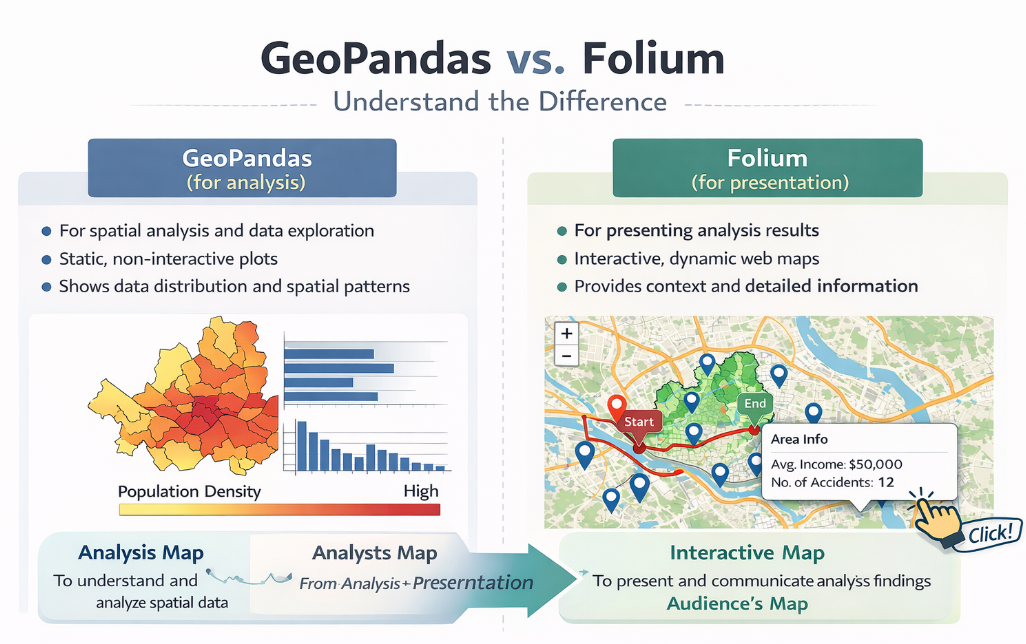

#### 0. 데이터 디렉토리 설정

In [3]:
BASE_DIR = os.getcwd() # 현재 작업 중인 프로젝트의 기본 경로
DATA_DIR = os.path.join(BASE_DIR, "data") # 데이터 파일이 저장된 폴더 경로
OUT_DIR  = os.path.join(BASE_DIR, "outputs") # 결과물(지도, 파일 등)을 저장할 폴더 경로

os.makedirs(OUT_DIR, exist_ok=True) # outputs 폴더가 없으면 생성 (이미 있으면 오류 없이 통과)

#### 1. 유틸 함수

In [4]:
def norm_nm(x):
    if pd.isna(x):
        return None # 결측값이면 None 반환

    s = str(x).strip().replace("\u00A0", " ") # 문자열로 변환 후 앞뒤 공백 제거, 특수 공백(NBSP)을 일반 공백으로 변환
    s = " ".join(s.split()) # 여러 개의 연속 공백을 하나의 공백으로 정리

    s = s.replace(".", "·") # 점(.)을 가운데점(·)으로 치환 (명칭 표준화 목적)
    return s

In [5]:
def read_csv_safely(path):
    try:
        return pd.read_csv(path, encoding="utf-8") # 기본적으로 UTF-8 인코딩으로 CSV 파일 읽기
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="cp949") # UTF-8 실패 시, 한글 Windows 환경(cp949)으로 재시도

#### 2. 데이터 로드

In [6]:
ADMIN_GPKG = os.path.join(OUT_DIR, "demo_admin.gpkg") # 행정구역 공간데이터가 저장된 GeoPackage 파일 경로

gdf_admin = gpd.read_file(ADMIN_GPKG) # GeoPackage 파일을 GeoDataFrame으로 불러오기
gdf_admin = gdf_admin.copy() # 원본 보호를 위해 GeoDataFrame 복사본 생성

In [7]:
ADMIN_NM_COL = "region_nm" # 행정구역 명칭이 들어 있는 컬럼명

gdf_admin["region_nm"] = gdf_admin[ADMIN_NM_COL].map(norm_nm) # 행정구역 명칭을 표준화 함수(norm_nm)로 정규화
gdf_admin = gdf_admin.to_crs(5179) # 좌표계를 EPSG:5179 (Korea 2000 / Central Belt)로 변환

In [8]:
UNCOVERED_GPKG = os.path.join(OUT_DIR, "demo_uncovered.gpkg") # 비커버(접근 불가) 영역이 저장된 GeoPackage 파일 경로

gdf_unc = gpd.read_file(UNCOVERED_GPKG) # 비커버 영역 공간데이터를 GeoDataFrame으로 불러오기

In [9]:
final_names = gdf_admin["region_nm"].dropna().unique().tolist() # 행정구역 데이터에 존재하는 지역명 목록 생성
gdf_unc_sel = gdf_unc[gdf_unc["region_nm"].isin(final_names)].copy() # 비커버 데이터 중 행정구역에 포함된 지역만 선택

In [10]:
BUS_XLSX = os.path.join(DATA_DIR, "서울시버스정류소위치정보(20260108).xlsx") # 서울시 버스정류소 위치정보 엑셀 파일 경로

bus_raw = pd.read_excel(BUS_XLSX) # 버스정류소 위치 데이터를 DataFrame으로 불러오기

In [11]:
BUS_LON_COL, BUS_LAT_COL = "X좌표", "Y좌표" # 버스정류소 경도(X), 위도(Y) 컬럼명

bus_raw[BUS_LON_COL] = pd.to_numeric(bus_raw[BUS_LON_COL], errors="coerce")
bus_raw[BUS_LAT_COL] = pd.to_numeric(bus_raw[BUS_LAT_COL], errors="coerce") # 좌표 값을 숫자형으로 변환 (변환 불가 값은 NaN 처리)

bus_raw = bus_raw.dropna(subset=[BUS_LON_COL, BUS_LAT_COL]).copy() # 좌표가 없는 행 제거 후 복사본 생성

In [12]:
gdf_bus = gpd.GeoDataFrame(
    bus_raw,
    geometry=gpd.points_from_xy(bus_raw[BUS_LON_COL], bus_raw[BUS_LAT_COL]), # X, Y 좌표로 Point 지오메트리 생성
    crs="EPSG:4326" # 원본 좌표계: WGS84 (경위도)
).to_crs(5179) # GeoDataFrame 생성 후 EPSG:5179 (국가좌표계)로 변환

In [13]:
SUBWAY_CSV = os.path.join(DATA_DIR, "서울교통공사_1_8호선 역사 좌표(위경도) 정보_20250814.csv") # 서울 지하철 1~8호선 역사 좌표 CSV 파일 경로

sub_raw = read_csv_safely(SUBWAY_CSV) # 인코딩 오류를 고려해 안전하게 CSV 파일 읽기

In [14]:
SUB_LON_COL, SUB_LAT_COL = "경도", "위도" # 지하철 역사 경도, 위도 컬럼명

sub_raw[SUB_LON_COL] = pd.to_numeric(sub_raw[SUB_LON_COL], errors="coerce")
sub_raw[SUB_LAT_COL] = pd.to_numeric(sub_raw[SUB_LAT_COL], errors="coerce") # 좌표 값을 숫자형으로 변환 (변환 불가 값은 NaN 처리)

sub_raw = sub_raw.dropna(subset=[SUB_LON_COL, SUB_LAT_COL]).copy() # 좌표가 없는 행 제거 후 복사본 생성

In [15]:
gdf_sub = gpd.GeoDataFrame(
    sub_raw,
    geometry=gpd.points_from_xy(sub_raw[SUB_LON_COL], sub_raw[SUB_LAT_COL]), # 경도·위도 좌표로 Point 지오메트리 생성
    crs="EPSG:4326" # 원본 좌표계: WGS84 (경위도)
).to_crs(5179) # GeoDataFrame 생성 후 EPSG:5179 (국가좌표계)로 변환

In [16]:
BIKE_CSV = os.path.join(DATA_DIR, "서울시 따릉이대여소 마스터 정보.csv") # 서울시 따릉이 대여소 마스터 정보 CSV 파일 경로

bike_raw = read_csv_safely(BIKE_CSV) # 인코딩 오류를 고려해 안전하게 CSV 파일 읽기

In [17]:
BIKE_ID_COL, BIKE_ADR_COL = "대여소_ID", "주소1" # 따릉이 대여소 ID와 주소 컬럼명
BIKE_LAT_COL, BIKE_LON_COL = "위도", "경도" # 따릉이 대여소 위도, 경도 컬럼명

bike_raw[BIKE_LAT_COL] = pd.to_numeric(bike_raw[BIKE_LAT_COL], errors="coerce")
bike_raw[BIKE_LON_COL] = pd.to_numeric(bike_raw[BIKE_LON_COL], errors="coerce") # 좌표 값을 숫자형으로 변환 (변환 불가 값은 NaN 처리)

bike_raw = bike_raw.dropna(subset=[BIKE_LAT_COL, BIKE_LON_COL]).copy() # 좌표가 없는 행 제거
bike_raw = bike_raw[(bike_raw[BIKE_LAT_COL] != 0) & (bike_raw[BIKE_LON_COL] != 0)].copy() # 위·경도가 0인 비정상 좌표 제거

In [18]:
gdf_bike = gpd.GeoDataFrame(
    bike_raw,
    geometry=gpd.points_from_xy(bike_raw[BIKE_LON_COL], bike_raw[BIKE_LAT_COL]), # 경도·위도 좌표로 Point 지오메트리 생성
    crs="EPSG:4326" # 원본 좌표계: WGS84 (경위도)
).to_crs(5179) # GeoDataFrame 생성 후 EPSG:5179 (국가좌표계)로 변환

#### Folium 지도(Tile) 선택 기준 이해하기
- Folium에서 사용하는 지도 타일은 단순한 배경이 아니라, 분석 결과의 가독성과 해석 방향에 직접적인 영향을 주는 요소다.
- 따라서 실습 단계에서는 “아무 타일이나” 쓰는 것이 아니라, 분석 목적에 맞는 타일을 의도적으로 선택하는 습관이 필요하다.

##### 실습이 목적일 때는 안정성을 최우선으로 선택한다
- 실습 환경(VS Code, Jupyter, Colab 등)에 따라 타일이 안 뜨면 분석 흐름이 끊기게 된다.
- 이 단계에서는 시각적 완성도보다 환경 의존성이 가장 낮은 기본 타일을 사용하는 것이 좋다.
- tiles="OpenStreetMap" → 실습·과제·초기 코드 작성 단계의 기본값으로 사용한다.

##### 결과를 보여주는 단계에서는 지도 가독성을 고려한다
- 분석이 끝난 뒤에는 “무엇을 분석했는지”가 한눈에 보이는 지도가 필요하다.
- 도로 구조와 도시 맥락이 잘 보이면, 이동 경로·접근성·네트워크 결과를 설명하기가 훨씬 쉽다.
- 이 단계에서는 배경과 분석 결과가 동시에 읽히는 타일을 선택하는 것이 중요하다.
- tiles="CartoDB Voyager" → 결과 공유, 발표용 지도, 보고서 이미지에 적합하다.

##### 분석 결과 자체를 설명해야 할 때는 배경을 최대한 단순화한다
- 취약지역, 비커버 지역, 클러스터처럼 분석 결과가 핵심인 경우 지도 배경이 복잡하면 오히려 해석을 방해한다.
- 이때는 도시 맥락보다 분석 레이어가 가장 먼저 눈에 들어와야 한다.
- tiles="CartoDB Positron" → 정책 해석, 공간 패턴 설명, 분석 결과 비교에 적합하다.

##### 왜 타일 선택이 중요한가?
- 같은 분석 결과라도 타일에 따라 보이는 인상과 해석이 달라진다.
- 배경이 강하면 결과가 묻히고, 배경이 약하면 분석이 드러난다.
- 따라서 타일 선택은 디자인 문제가 아니라 분석 커뮤니케이션의 문제다.

In [19]:
# 행정구역 내부 컷(+ region_nm 부여)
gdf_bus_sel = gpd.sjoin(
    gdf_bus[["geometry"]], # 버스정류소 포인트
    gdf_admin[["region_nm", "geometry"]], # 행정구역 폴리곤 (지역명 포함)
    how="inner", # 행정구역 안에 포함된 경우만 유지
    predicate="within"
).drop(columns=["index_right"]) # 공간조인 과정에서 생성된 불필요한 인덱스 컬럼 제거

#### Folium 시각화 시 EPSG:4326을 사용하는 이유

Folium은 내부적으로 **Leaflet.js**를 기반으로 동작하며, Leaflet은 모든 공간 객체를 **경도·위도(longitude, latitude)** 좌표로 해석한다.  
이때 사용하는 표준 좌표계가 **EPSG:4326 (WGS84)** 이다.

투영좌표계(EPSG:5179 등)는 단위가 미터인 평면 좌표계이므로, 이를 그대로 Folium에 전달하면 좌표가 잘못 해석되어  
객체가 엉뚱한 위치에 표시되거나 보이지 않는 문제가 발생한다.

또한 Folium에서 사용하는 **OpenStreetMap, CartoDB 등의 베이스맵 타일**은  
모두 WGS84 기반 좌표 입력을 전제로 하므로, 사용자 데이터 역시 EPSG:4326으로 맞춰야 정확히 겹쳐진다.

##### 실무 기준 좌표계 사용 원칙

- **공간 분석 단계**  
  - EPSG:5179 (국가좌표계, 단위: m)  
  - 거리·면적 계산, 버퍼, 커버리지 분석에 적합

- **지도 시각화 단계 (Folium)**  
  - EPSG:4326 (WGS84, 경위도)  
  - Leaflet 기반 웹 지도 표준

In [20]:
admin_ll = gdf_admin.to_crs(4326) # 행정구역 데이터를 WGS84(경위도) 좌표계로 변환
unc_ll   = gdf_unc_sel.to_crs(4326) # 비커버 영역 데이터를 WGS84 좌표계로 변환
bus_ll   = gdf_bus_sel.to_crs(4326) # 버스정류소 데이터를 WGS84 좌표계로 변환

bounds = admin_ll.total_bounds # 행정구역 전체의 최소/최대 경도·위도 범위 계산

center_lat = (bounds[1] + bounds[3]) / 2
center_lon = (bounds[0] + bounds[2]) / 2 # 지도 초기 중심 좌표 계산

In [21]:
m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles="OpenStreetMap")
# 지도 객체 생성 (중심 좌표, 초기 줌, OSM 베이스맵)

# 1) 행정구역
folium.GeoJson(
    admin_ll,
    name="행정구역",
    style_function=lambda x: {"fillOpacity": 0.05, "color": "#666666", "weight": 2},
    # 행정구역 스타일 지정
    tooltip=folium.GeoJsonTooltip(fields=["region_nm"], aliases=["행정동"])
    # 행정동 이름 툴팁 표시
).add_to(m)

# 2) 비커버
folium.GeoJson(
    unc_ll,
    name="비커버 지역",
    style_function=lambda x: {"fillOpacity": 0.30, "color": "#cc0000", "weight": 1},
    # 비커버 지역 강조 스타일
    tooltip=folium.GeoJsonTooltip(fields=["region_nm"], aliases=["행정동"])
).add_to(m)

# 3) 버스정류장(클러스터)
fg_bus = folium.FeatureGroup(name="버스정류장(클러스터)", show=True)
# 버스정류장 레이어 그룹 생성

mc = MarkerCluster().add_to(fg_bus)
# 다수의 버스정류장을 클러스터링

for _, r in bus_ll.iterrows():
    folium.Marker(
        location=[r.geometry.y, r.geometry.x],
        # 버스정류장 위치
        tooltip=f"버스 | {r.get('region_nm','')}",
        # 툴팁에 행정동 정보 표시
        icon=folium.Icon(color="blue", icon="bus", prefix="fa")
        # FontAwesome 버스 아이콘 사용
    ).add_to(mc)

fg_bus.add_to(m)
# 버스정류장 레이어를 지도에 추가

m.fit_bounds([[bounds[1], bounds[0]], [bounds[3], bounds[2]]])
# 행정구역 전체가 보이도록 지도 범위 자동 조정

folium.LayerControl(collapsed=False).add_to(m)
# 레이어 ON/OFF 컨트롤 추가

# VS Code에서 지도 미표시 시: HTML로 저장해 브라우저에서 확인
OUT_HTML = os.path.join(OUT_DIR, "bus_admin_uncovered.html")
# 결과 지도 HTML 저장 경로

m.save(OUT_HTML)
# 지도 저장

OUT_HTML
# 저장된 HTML 파일 경로 출력

'c:\\_jupyter_workspace\\sparta\\gis_session\\outputs\\bus_admin_uncovered.html'

#### Folium 핵심 함수 한눈 요약

Folium은 **웹 지도 시각화 라이브러리**로, `지도 생성 → 레이어 추가 → 제어` 구조로 동작한다.

- **`folium.Map()`** : 지도의 시작점. 중심 좌표, 줌 레벨, 베이스맵 설정
- **`folium.GeoJson()`** : 행정구역·분석 영역 등 공간 객체(Polygon/Line) 시각화
- **`style_function`** : GeoJson의 색상, 두께, 투명도 등 시각적 스타일 지정
- **`folium.GeoJsonTooltip()`** : 마우스 오버 시 속성 정보 표시
- **`folium.FeatureGroup()`** : 여러 객체를 하나의 레이어로 묶음 (ON/OFF 가능)
- **`folium.Marker()`** : 개별 지점(Point) 표시
- **`folium.Icon()`** : 마커 아이콘 모양·색상 설정 (FontAwesome 지원)
- **`MarkerCluster`** : 다수의 마커를 자동으로 군집화
- **`fit_bounds()`** : 모든 객체가 보이도록 지도 범위 자동 조정
- **`folium.LayerControl()`** : 레이어 선택·비교 UI 제공
- **`save()`** : 지도를 HTML 파일로 저장

Folium Documentation : https://python-visualization.github.io/folium/latest/

In [22]:
gdf_sub_sel = gpd.sjoin(
    gdf_sub[["geometry"]], # 지하철 역사 포인트
    gdf_admin[["region_nm", "geometry"]], # 행정구역 폴리곤 (지역명 포함)
    how="inner", # 행정구역 내부에 포함된 지하철만 선택
    predicate="within"
).drop(columns=["index_right"]) # 공간조인 후 생성된 불필요한 인덱스 컬럼 제거

In [23]:
sub_ll = gdf_sub_sel.to_crs(4326) # 지하철 데이터를 Folium용 WGS84 좌표계로 변환

bounds = admin_ll.total_bounds
center_lat = (bounds[1] + bounds[3]) / 2
center_lon = (bounds[0] + bounds[2]) / 2 # 지도 범위 / 중심 좌표 계산

# 지도 생성 (CartoDB Positron 베이스맵)
m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles="cartodbpositron")

# 1) 행정구역 폴리곤
folium.GeoJson(
    admin_ll,
    name="행정구역",
    style_function=lambda x: {"fillOpacity": 0.05, "color": "#666666", "weight": 2},
    tooltip=folium.GeoJsonTooltip(fields=["region_nm"], aliases=["행정동"])
).add_to(m)

# 2) 비커버 지역 폴리곤
folium.GeoJson(
    unc_ll,
    name="비커버 지역",
    style_function=lambda x: {"fillOpacity": 0.30, "color": "#cc0000", "weight": 1},
    tooltip=folium.GeoJsonTooltip(fields=["region_nm"], aliases=["행정동"])
).add_to(m)

# 3) 버스정류장 (클러스터)
fg_bus = folium.FeatureGroup(name="버스정류장(클러스터)", show=True)
mc_bus = MarkerCluster().add_to(fg_bus)

for _, r in bus_ll.iterrows():
    folium.Marker(
        location=[r.geometry.y, r.geometry.x],
        tooltip=f"버스 | {r.get('region_nm','')}",
        icon=folium.Icon(color="blue", icon="bus", prefix="fa")
    ).add_to(mc_bus)

fg_bus.add_to(m)
# 버스 레이어 추가

# 4) 지하철역 (클러스터)
fg_sub = folium.FeatureGroup(name="지하철역(클러스터)", show=True)
mc_sub = MarkerCluster().add_to(fg_sub)

for _, r in sub_ll.iterrows():
    folium.Marker(
        location=[r.geometry.y, r.geometry.x],
        tooltip=f"지하철 | {r.get('region_nm','')}",
        icon=folium.Icon(color="green", icon="train", prefix="fa")
    ).add_to(mc_sub)

fg_sub.add_to(m)
# 지하철 레이어 추가

# 지도 범위 자동 조정 + 레이어 토글
m.fit_bounds([[bounds[1], bounds[0]], [bounds[3], bounds[2]]])
folium.LayerControl(collapsed=False).add_to(m)

# HTML 파일로 지도 저장
OUT_HTML = os.path.join(OUT_DIR, "admin_uncovered_bus_subway.html")
m.save(OUT_HTML)

OUT_HTML
# 저장된 지도 파일 경로 출력

'c:\\_jupyter_workspace\\sparta\\gis_session\\outputs\\admin_uncovered_bus_subway.html'

In [24]:
gdf_bike_sel = gpd.sjoin(
    gdf_bike[[BIKE_ID_COL, BIKE_ADR_COL, "geometry"]], # 따릉이 대여소 포인트 (ID, 주소 포함)
    gdf_admin[["region_nm", "geometry"]], # 행정구역 폴리곤 (지역명 포함)
    how="inner", # 행정구역 내부에 포함된 대여소만 선택
    predicate="within"
).drop(columns=["index_right"]) # 공간조인 후 생성된 불필요한 인덱스 컬럼 제거

In [25]:
bike_ll = gdf_bike_sel.to_crs(4326) # 따릉이 대여소 데이터를 Folium용 WGS84 좌표계로 변환

# 지도 범위 / 중심 좌표 계산
bounds = admin_ll.total_bounds
center_lat = (bounds[1] + bounds[3]) / 2
center_lon = (bounds[0] + bounds[2]) / 2

# 지도 생성 (CartoDB Voyager 베이스맵)
m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles="CartoDB Voyager")

# 1) 행정구역 폴리곤
folium.GeoJson(
    admin_ll,
    name="행정구역",
    style_function=lambda x: {"fillOpacity": 0.05, "color": "#666666", "weight": 2},
    tooltip=folium.GeoJsonTooltip(fields=["region_nm"], aliases=["행정동"])
).add_to(m)

# 2) 비커버 지역 폴리곤
folium.GeoJson(
    unc_ll,
    name="비커버 지역",
    style_function=lambda x: {"fillOpacity": 0.30, "color": "#cc0000", "weight": 1},
    tooltip=folium.GeoJsonTooltip(fields=["region_nm"], aliases=["행정동"])
).add_to(m)

# 3) 버스정류장 (클러스터)
fg_bus = folium.FeatureGroup(name="버스정류장(클러스터)", show=True)
mc_bus = MarkerCluster().add_to(fg_bus)

for _, r in bus_ll.iterrows():
    folium.Marker(
        location=[r.geometry.y, r.geometry.x],
        tooltip=f"버스 | {r.get('region_nm','')}",
        icon=folium.Icon(color="blue", icon="bus", prefix="fa")
    ).add_to(mc_bus)

fg_bus.add_to(m)
# 버스 레이어 추가

# 4) 지하철역 (클러스터)
fg_sub = folium.FeatureGroup(name="지하철역(클러스터)", show=True)
mc_sub = MarkerCluster().add_to(fg_sub)

for _, r in sub_ll.iterrows():
    folium.Marker(
        location=[r.geometry.y, r.geometry.x],
        tooltip=f"지하철 | {r.get('region_nm','')}",
        icon=folium.Icon(color="green", icon="train", prefix="fa")
    ).add_to(mc_sub)

fg_sub.add_to(m)
# 지하철 레이어 추가

# 5) 따릉이 대여소 (클러스터)
fg_bike = folium.FeatureGroup(name="따릉이(클러스터)", show=True)
mc_bike = MarkerCluster().add_to(fg_bike)

for _, r in bike_ll.iterrows():
    tip = f"따릉이 | {r.get('region_nm','')} | {r.get('대여소_ID','')} | {r.get('주소1','')}"
    folium.Marker(
        location=[r.geometry.y, r.geometry.x],
        tooltip=tip,
        icon=folium.Icon(color="orange", icon="bicycle", prefix="fa")
    ).add_to(mc_bike)

fg_bike.add_to(m)
# 따릉이 레이어 추가

# 지도 범위 자동 조정 + 레이어 토글
m.fit_bounds([[bounds[1], bounds[0]], [bounds[3], bounds[2]]])
folium.LayerControl(collapsed=False).add_to(m)

# HTML 파일로 지도 저장
OUT_HTML = os.path.join(OUT_DIR, "admin_uncovered_bus_subway_bike.html")
m.save(OUT_HTML)

OUT_HTML
# 저장된 지도 파일 경로 출력

'c:\\_jupyter_workspace\\sparta\\gis_session\\outputs\\admin_uncovered_bus_subway_bike.html'

#### 3. OSMnx · NetworkX 기반 최단경로 알고리즘

이 파트의 목적은 **따릉이 대여소에서 출발해 실제 도로(보행 네트워크)를 따라  
5분 이내에 도달 가능한 버스정류장·지하철역과 그 경로를 계산하는 것**이다.  
직선거리가 아니라 OpenStreetMap 도로망 위 이동 경로를 기준으로 접근성을 분석한다.

먼저 행정동 폴리곤을 하나로 합치고(union), 경계에서 네트워크가 끊기는 문제를 방지하기 위해 일정 거리의 버퍼를 적용한다.  
이 폴리곤을 EPSG:4326(WGS84)으로 변환한 뒤 `graph_from_polygon()`을 사용해 보행 네트워크 그래프를 생성한다.

따릉이 대여소와 정류장·역은 좌표(Point) 데이터이지만, NetworkX의 최단경로 계산은 **그래프 노드 ID 기반**으로 수행된다.  
따라서 `nearest_nodes()`를 이용해 출발지와 목적지를 가장 가까운 그래프 노드에 스냅한다.  
이때 여러 정류장이 동일한 노드에 매칭될 수 있으므로 노드–정류장 매핑을 통해 결과 누락을 방지한다.

각 따릉이 대여소(출발 노드)에 대해 `single_source_dijkstra_path_length()`를 사용해  
**5분 이동거리(cutoff) 이내에 도달 가능한 노드만** 먼저 계산한다.  
이는 모든 정류장에 대해 경로를 계산하는 비효율을 줄이기 위한 단계다.  
이후 해당 범위 안에 있는 정류장 노드만 선별해 `shortest_path()`로 실제 최단경로를 복원한다.

복원된 경로는 LineString으로 생성하며, 길이 계산은 경위도 좌표계가 아닌 **미터 단위 투영좌표계(EPSG:5179)** 에서 수행한다.  
이를 통해 거리(m)와 소요시간(분)을 산출하고, 최종적으로 따릉이에서 버스·지하철까지의 5분 이내 접근 경로를 지도 레이어로 시각화한다.

In [26]:
# OSMnx로 도로/보행 네트워크를 생성할 때는 "분석 대상 지역을 감싸는 하나의 폴리곤"이 필요하다.
# 행정동이 여러 개로 나뉘어 있으면 네트워크가 끊기거나 경계 부근에서 경로 탐색이 실패할 수 있으므로,
# 전체 지역을 하나로 합치고 충분한 버퍼를 준다.

poly_union_5179 = gdf_admin.geometry.union_all().buffer(0)
# 모든 행정구역 폴리곤을 하나로 병합
# buffer(0)은 미세한 지오메트리 오류를 정정하기 위한 관행적 처리

poly_buf_5179 = poly_union_5179.buffer(8000)
# 행정구역 경계 바깥까지 경로가 자연스럽게 이어지도록 8km 버퍼를 적용해 분석 범위를 확장 (단위: m)

poly_buf_4326 = (
    gpd.GeoSeries([poly_buf_5179], crs=5179)
    .to_crs(4326)
    .iloc[0]
) # OSMnx는 WGS84(EPSG:4326) 좌표계를 사용하므로 네트워크 생성 입력용 폴리곤으로 좌표계 변환

In [27]:
ox.settings.log_console = False # OSMnx 실행 시 콘솔에 출력되는 로그 메시지 비활성화

G = ox.graph_from_polygon(
    poly_buf_4326,
    network_type="walk",
    simplify=True
)
# 지정한 폴리곤 영역 내에서 보행자(walk) 도로 네트워크 그래프 생성
# simplify=True : 불필요한 노드 제거 및 도로 단순화

In [28]:
gdf_bike_ll = gdf_bike_sel.to_crs(4326) # OSMnx / NetworkX 경로 탐색에 사용하기 위해 따릉이 대여소 좌표계를 WGS84(EPSG:4326)로 변환

In [29]:
# 이후 단계에서 지역(region_nm)별로 라우팅·거리 계산을 반복 수행하게 되는데,
# 매번 전체 버스/지하철 데이터를 필터링하면 연산 비용이 커진다.

# groupby("region_nm") 결과를 딕셔너리로 미리 만들어 두면,
# 특정 지역의 버스·지하철만 즉시 조회할 수 있어 처리 속도가 크게 개선된다.

bus_group = {k: v for k, v in gdf_bus_sel.groupby("region_nm")} # {지역명: 해당 지역의 버스정류소 GeoDataFrame}
sub_group = {k: v for k, v in gdf_sub_sel.groupby("region_nm")} # {지역명: 해당 지역의 지하철역 GeoDataFrame}

In [30]:
BIKE_SPEED_KMH = 15 # 따릉이 평균 이동 속도 (km/h)
TIME_MIN = 5 # 접근성 분석 기준 시간 (분)

# 15 km/h → 250 m/min → 5분 = 1,250 m
CUTOFF_M = BIKE_SPEED_KMH * 1000 / 60 * TIME_MIN # 시간 기준을 거리 기준(m)으로 변환한 라우팅 컷오프 값

routes = [] # 계산된 경로(LineString) 결과 저장용 리스트
fails = [] # 경로 탐색 실패 사례 기록용 리스트

In [31]:
gdf_bus_5179 = gdf_bus_sel.copy()
# 버스정류소 데이터 복사 / 이후 버스·지하철 데이터를 하나로 합쳐 처리하기 위해 원본 보호

gdf_bus_5179["stop_type"] = "bus"
# 정류소 유형 구분용 컬럼 추가 (버스/지하철을 동일 로직으로 처리하면서도 구분 가능하게 함)

gdf_sub_5179 = gdf_sub_sel.copy()
# 지하철역 데이터 복사 / 이후 통합 및 라우팅 계산을 위한 전처리 단계

gdf_sub_5179["stop_type"] = "subway"
# 정류소 유형 구분용 컬럼 추가 / # 분석 결과 해석 및 시각화 시 유형별 구분에 사용

In [32]:
gdf_stop_5179 = pd.concat([gdf_bus_5179, gdf_sub_5179], ignore_index=True) # 버스·지하철 정류소 데이터를 하나의 테이블로 통합

gdf_stop_5179 = gpd.GeoDataFrame(
    gdf_stop_5179,
    geometry="geometry",
    crs=5179
) # 통합된 데이터를 GeoDataFrame으로 변환하고 좌표계 지정

gdf_stop_ll = gdf_stop_5179.to_crs(4326) # Folium / OSMnx 사용을 위해 WGS84(EPSG:4326) 좌표계로 변환

#### 노드(Node)와 링크(Link)

네트워크 분석은 공간을 **그래프 구조**로 표현한다.

- **노드(Node)**  
  이동이 시작·종료되는 지점  
  (교차로, 도로 끝, 정류소가 매칭되는 위치)

- **링크(Link / Edge)**  
  두 노드를 연결하는 이동 가능한 경로  
  (도로, 보행로, 자전거도로)

경로 탐색과 거리 계산은 노드 간 링크의 가중치(거리·시간)를 기준으로 수행된다.

**정류소·출발지는 반드시 노드에 스냅되어야 하며, 네트워크 분석은 노드–링크 구조 위에서만 가능하다.**

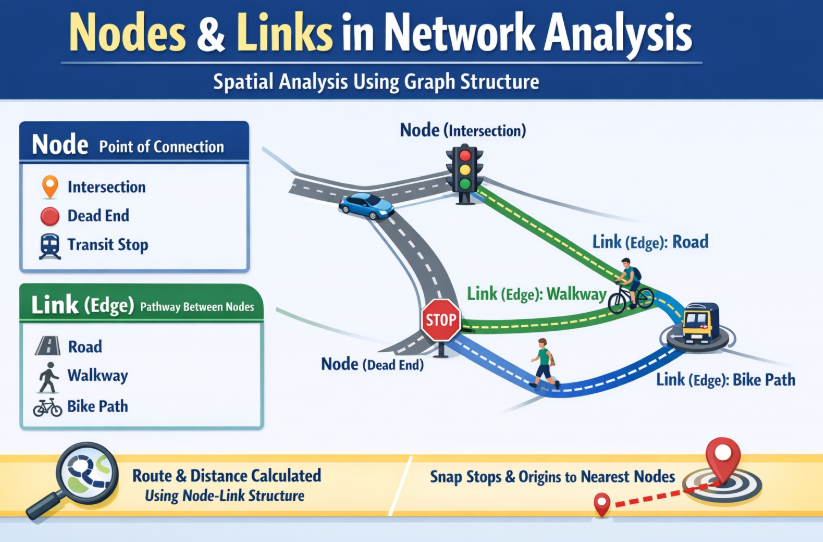

In [33]:
try:
    stop_nodes = ox.distance.nearest_nodes(
        G,
        X=gdf_stop_ll.geometry.x.values,
        Y=gdf_stop_ll.geometry.y.values
    )
    # 각 정류소(Point)를 도로 네트워크 그래프(G) 상의 가장 가까운 노드(node)에 매칭(스냅)

    gdf_stop_ll["v_node"] = stop_nodes # 이후 라우팅 계산에 사용할 그래프 노드 ID 저장

except Exception as e:
    raise RuntimeError(f"정류장 스냅 실패: {e}")
    # 네트워크 생성 오류나 좌표 문제 발생 시 명확한 에러 메시지 출력

In [34]:
# 정류장 좌표를 nearest_nodes로 스냅하면, 서로 가까운 정류장들이 동일한 그래프 노드(v_node)에 매칭되는 경우가 흔함

node_to_stops = {}
# key: 그래프 노드 ID(v_node)
# value: 해당 노드에 스냅된 정류장(행) 인덱스 리스트

for i, row in gdf_stop_ll.iterrows():
    # gdf_stop_ll의 각 정류장(버스/지하철) 행을 순회
    # i는 DataFrame의 행 인덱스(여기서는 stop의 식별자처럼 사용)
    v = row["v_node"]
    # 해당 정류장이 스냅된 그래프 노드 ID

    node_to_stops.setdefault(v, []).append(i)
    # node_to_stops에 v 키가 없으면 빈 리스트를 만들고, 현재 정류장 인덱스 i를 그 리스트에 추가
    # 결과적으로: node_to_stops[v] = [i1, i2, i3, ...] 형태로 "노드 v에 매칭된 정류장들"을 빠르게 조회 가능

stop_node_set = set(node_to_stops.keys())
# 정류장이 존재하는 그래프 노드 ID만 모은 집합(set) 이후 라우팅/도달성 계산에서 "후보 목적지 노드"를 빠르게 필터링할 때 유용

In [35]:
for idx, br in gdf_bike_sel.iterrows():
    # 따릉이 대여소(출발지) 한 곳씩 순회
    # idx: 행 인덱스, br: 해당 행(Series)

    region_nm = br.get("region_nm", "")
    bike_id   = br.get(BIKE_ID_COL, "")
    bike_adr  = br.get(BIKE_ADR_COL, "")
    # 출발 대여소의 지역명/ID/주소 메타 정보 추출

    bike_pt_ll = gdf_bike_ll.loc[idx].geometry  # 4326
    # Folium/OSMnx 라우팅용 WGS84 좌표의 Point 가져오기

    # -------------------------
    # 1) 출발지 Point → 그래프 노드(u)로 스냅
    # -------------------------
    try:
        u = ox.distance.nearest_nodes(G, bike_pt_ll.x, bike_pt_ll.y)
        # 출발 좌표(경도 x, 위도 y)에 가장 가까운 그래프 노드 ID(u) 반환
        # ※ NetworkX 라우팅은 노드 ID 기반으로만 수행되므로 필수 단계
    except Exception as e:
        # 스냅 실패(좌표 이상, 그래프 범위 밖 등) 기록 후 다음 대여소로
        fails.append({"region_nm": region_nm, "bike_id": bike_id, "type": "snap_src", "error": str(e)})
        continue

    # -------------------------
    # 2) u 기준, 5분 거리(CUTOFF_M) 안의 노드까지 최단거리(미터) 계산
    # -------------------------
    # single_source_dijkstra_path_length:
    #   source=u에서 출발하여 cutoff(거리 한계) 안에 있는 모든 노드까지의
    #   최단거리 맵(dist_map)을 계산한다.
    # weight="length":
    #   엣지 가중치로 OSMnx가 넣어둔 length(미터)를 사용한다.
    try:
        dist_map = nx.single_source_dijkstra_path_length(
            G, source=u, cutoff=CUTOFF_M, weight="length"
        )
        # dist_map: {노드ID: u로부터 최단거리(m), ...}
    except Exception as e:
        fails.append({"region_nm": region_nm, "bike_id": bike_id, "type": "dijkstra_cutoff", "error": str(e)})
        continue

    # -------------------------
    # 3) cutoff 안에 들어온 노드 중 "정류장 노드"만 필터링
    # -------------------------
    candidate_stop_nodes = [n for n in dist_map.keys() if n in stop_node_set]
    # dist_map에 포함된 노드들(=5분 이내 도달 가능 후보) 중
    # 정류장이 스냅된 노드(stop_node_set)만 남김

    # 후보 정류장 노드가 없으면 기록하고 다음 대여소로
    if len(candidate_stop_nodes) == 0:
        fails.append({"region_nm": region_nm, "bike_id": bike_id, "type": "no_stop_within_5min", "error": ""})
        continue

    # -------------------------
    # 4) 각 후보 정류장 노드(v)에 대해 최단경로를 복원하고 라인 생성
    # -------------------------
    for v in candidate_stop_nodes:
        try:
            nodes = nx.shortest_path(G, u, v, weight="length")
            # u→v 최단경로를 "노드 리스트" 형태로 복원
            # (거리만이 아니라, 실제 경로 도형을 만들기 위해 필요)

            xs = [G.nodes[n]["x"] for n in nodes]
            ys = [G.nodes[n]["y"] for n in nodes]
            # 그래프 노드에 저장된 좌표(x=경도, y=위도)를 추출

            line_ll = LineString(list(zip(xs, ys)))
            # 노드 좌표를 연결해 경로(LineString) 생성 (WGS84 좌표)

            # -------------------------
            # 5) 경로 길이/시간 계산
            # -------------------------
            length_m = float(
                gpd.GeoSeries([line_ll], crs=4326).to_crs(5179).iloc[0].length
            )
            # LineString을 5179(미터 단위)로 투영해 길이(m) 계산
            # (4326은 도(degree) 단위라 길이 계산에 부적절)

            duration_min = (length_m / 1000) / BIKE_SPEED_KMH * 60
            # 길이(m) → km로 변환 후 속도(km/h)로 시간(분) 산출

            # -------------------------
            # 6) 같은 v 노드에 여러 정류장이 붙을 수 있으므로 모두 기록
            # -------------------------
            stop_idx_list = node_to_stops.get(v, [])
            # v 노드에 스냅된 정류장 행 인덱스 리스트 조회

            for stop_i in stop_idx_list:
                stop_row = gdf_stop_ll.loc[stop_i]
                # 정류장(버스/지하철) 한 건의 메타 정보

                routes.append({
                    "region_nm": region_nm,
                    "bike_id": bike_id,
                    "bike_addr": bike_adr,

                    # 정류장 메타 (보유 데이터 컬럼명에 맞게 get으로 유연하게 처리)
                    "stop_type": stop_row.get("stop_type", ""),
                    "stop_id": stop_row.get("stop_id", stop_row.get("station_id", "")),
                    "stop_nm": stop_row.get("stop_nm", stop_row.get("station_nm", "")),

                    "length_m": length_m,
                    "duration_min": duration_min,
                    "geometry": line_ll
                })
                # 출발(따릉이) → 정류장 경로 1건을 결과 리스트에 저장

        except Exception as e:
            # 경로 복원/라인 생성/길이 계산 등 중 오류 발생 시 기록
            fails.append({"region_nm": region_nm, "bike_id": bike_id, "type": "route_build", "error": str(e)})

print("routes:", len(routes), "| fails:", len(fails))
# 전체 성공 경로 수와 실패 건수 출력

routes: 508 | fails: 8


#### 이 블록에서 꼭 알아야 할 핵심 함수(실무 필수)

##### 1) GeoDataFrame.iterrows()
- 행 단위로 순회하며 Point(출발지)를 하나씩 처리할 때 사용  
- 대규모 데이터에서는 느릴 수 있어, 필요 시 벡터화/병렬화 고려
##### 2) ox.distance.nearest_nodes(G, X, Y)
- 좌표(경도 X, 위도 Y)를 **그래프 노드 ID**로 스냅(snapping)  
- 라우팅은 노드 기반이므로 **출발지/도착지 모두 필수 선행 단계**
##### 3) nx.single_source_dijkstra_path_length(G, source, cutoff, weight)
- source에서 출발해 **cutoff(거리 한계)** 안에 있는 노드까지의 최단거리 계산  
- 반환값은 `{node_id: distance}` 형태의 거리 맵  
- “5분 이내 도달 가능한 후보 노드만 빠르게 뽑기”에 최적
##### 4) nx.shortest_path(G, u, v, weight)
- u→v 최단경로를 **노드 리스트**로 복원  
- 거리만이 아니라 “경로 선(LineString)”을 만들려면 필요
##### 5) LineString([...])
- 노드 좌표들을 연결해 **경로 도형** 생성  
- 이후 지도 시각화/길이 계산/결과 저장의 핵심 geometry
##### 6) GeoSeries(...).to_crs(5179).length
- 경로 길이 계산은 **미터 단위 투영좌표계(예: 5179)** 에서 수행  
- 4326(경위도)은 degree 단위라 길이 계산에 부적절
##### 7) dict.setdefault(key, default)
- 같은 노드에 여러 정류장이 매칭될 때  
- node_id -> [stop_index들] 형태로 묶는 데 유용

In [36]:
routes_gdf = gpd.GeoDataFrame(routes, geometry="geometry", crs=4326) # 경로 결과를 GeoDataFrame으로 변환
fails_df = pd.DataFrame(fails) # 실패 사례를 DataFrame으로 정리

In [37]:
OUT_GPKG_ALL = os.path.join(OUT_DIR, "routes_all.gpkg") # 모든 경로 결과를 저장할 GeoPackage 파일 경로
OUT_FAIL_CSV = os.path.join(OUT_DIR, "routes_fail.csv") # 경로 탐색 실패 내역을 저장할 CSV 파일 경로

LAYER_ALL = "routes_5min_all" # 전체 경로 레이어명
LAYER_BUS = "routes_5min_bus" # 버스 정류장으로 연결된 경로 레이어명
LAYER_SUBWAY = "routes_5min_subway" # 지하철역으로 연결된 경로 레이어명

In [38]:
gdf_routes = gpd.GeoDataFrame(routes, geometry="geometry", crs=4326) # 경로 결과를 GeoDataFrame으로 변환
df_fails = pd.DataFrame(fails) # 실패 내역을 DataFrame으로 변환
df_fails.to_csv(OUT_FAIL_CSV, index=False, encoding="utf-8-sig") # 실패 내역을 CSV 파일로 저장

# 기존 GeoPackage 파일이 있으면 삭제
if os.path.exists(OUT_GPKG_ALL):
    os.remove(OUT_GPKG_ALL)

In [39]:
if len(gdf_routes) > 0:
    # 전체 경로를 GeoPackage에 저장
    gdf_routes.to_file(OUT_GPKG_ALL, layer=LAYER_ALL, driver="GPKG")

    # stop_type(버스/지하철)별로 레이어 분리 저장
    if "stop_type" in gdf_routes.columns:
        gdf_bus = gdf_routes[gdf_routes["stop_type"] == "bus"].copy()
        gdf_sub = gdf_routes[gdf_routes["stop_type"] == "subway"].copy()

        if len(gdf_bus) > 0:
            gdf_bus.to_file(OUT_GPKG_ALL, layer=LAYER_BUS, driver="GPKG")
        if len(gdf_sub) > 0:
            gdf_sub.to_file(OUT_GPKG_ALL, layer=LAYER_SUBWAY, driver="GPKG")
else:
    # 경로 결과가 없을 경우 경고 출력
    print("[WARN] gdf_routes is empty. GPKG not created. Check routes_fail.csv")

# 저장 결과 안내
print("Saved:")
print(" -", OUT_GPKG_ALL)
print(" -", OUT_FAIL_CSV)
print("Layers in gpkg:", [LAYER_ALL, LAYER_BUS, LAYER_SUBWAY])

Saved:
 - c:\_jupyter_workspace\sparta\gis_session\outputs\routes_all.gpkg
 - c:\_jupyter_workspace\sparta\gis_session\outputs\routes_fail.csv
Layers in gpkg: ['routes_5min_all', 'routes_5min_bus', 'routes_5min_subway']


In [40]:
if len(gdf_routes) > 0:
    # 경로 결과가 하나라도 있을 때만 저장 수행

    if "stop_type" in gdf_routes.columns:
        # stop_type 기준으로 경로 분리 저장

        # 버스 정류장으로 가는 경로
        gdf_bus = gdf_routes[gdf_routes["stop_type"] == "bus"]
        if len(gdf_bus) > 0:
            gdf_bus.to_file(
                OUT_GPKG_ALL,
                layer="bike_to_bus_5min",
                driver="GPKG"
            )

        # 지하철역으로 가는 경로
        gdf_sub = gdf_routes[gdf_routes["stop_type"] == "subway"]
        if len(gdf_sub) > 0:
            gdf_sub.to_file(
                OUT_GPKG_ALL,
                layer="bike_to_subway_5min",
                driver="GPKG"
            )
else:
    # 저장할 경로가 없을 경우 경고 출력
    print("[WARN] gdf_routes is empty. Nothing was saved.")

# 저장 결과 안내
print("저장 완료:", OUT_GPKG_ALL, "| fails:", OUT_FAIL_CSV)

저장 완료: c:\_jupyter_workspace\sparta\gis_session\outputs\routes_all.gpkg | fails: c:\_jupyter_workspace\sparta\gis_session\outputs\routes_fail.csv


In [41]:
OUT_HTML = os.path.join(OUT_DIR, "lecture3_map_with_uncovered_routes_5min.html")
# 결과 지도를 저장할 HTML 파일 경로

m = folium.Map(location=[37.55, 126.98], zoom_start=12, tiles="cartodbpositron")
# Folium 지도 생성 (중심 좌표, 줌, CartoDB 배경지도)

# (1) 행정구역 폴리곤
folium.GeoJson(
    gdf_admin.to_crs(4326),
    name="행정동(선택)",
    style_function=lambda x: {"fillOpacity": 0.05, "color": "#666666", "weight": 2},
    tooltip=folium.GeoJsonTooltip(fields=["region_nm"], aliases=["행정동"])
).add_to(m)

# (2) 비커버 지역 폴리곤
folium.GeoJson(
    gdf_unc_sel.to_crs(4326),
    name="비커버 지역",
    style_function=lambda x: {"fillOpacity": 0.30, "color": "#cc0000", "weight": 1},
    tooltip=folium.GeoJsonTooltip(fields=["region_nm"], aliases=["행정동"])
).add_to(m)

# (3) 버스정류장 마커
fg_bus = folium.FeatureGroup(name="버스정류장", show=False)
for _, r in gdf_bus_sel.to_crs(4326).iterrows():
    folium.Marker(
        location=[r.geometry.y, r.geometry.x],
        icon=folium.Icon(color="blue", icon="bus", prefix="fa"),
        tooltip=f"버스 | {r.get('region_nm','')}"
    ).add_to(fg_bus)
fg_bus.add_to(m)

# (4) 지하철역 마커
fg_sub = folium.FeatureGroup(name="지하철역", show=False)
for _, r in gdf_sub_sel.to_crs(4326).iterrows():
    folium.Marker(
        location=[r.geometry.y, r.geometry.x],
        icon=folium.Icon(color="green", icon="train", prefix="fa"),
        tooltip=f"지하철 | {r.get('region_nm','')}"
    ).add_to(fg_sub)
fg_sub.add_to(m)

# (5) 따릉이 대여소 (클러스터)
fg_bike = folium.FeatureGroup(name="따릉이(클러스터)", show=True)
mc = MarkerCluster().add_to(fg_bike)

for _, r in gdf_bike_sel.to_crs(4326).iterrows():
    tip = f"[{r.get('region_nm','')}] {r.get(BIKE_ID_COL,'')} | {r.get(BIKE_ADR_COL,'')}"
    folium.Marker(
        location=[r.geometry.y, r.geometry.x],
        icon=folium.Icon(color="orange", icon="bicycle", prefix="fa"),
        tooltip=tip
    ).add_to(mc)

fg_bike.add_to(m)

# (6) 5분 이내 접근 경로 (버스 / 지하철 분리)
fg_r_bus = folium.FeatureGroup(name="경로(5분 이내 → 버스)", show=False)
fg_r_sub = folium.FeatureGroup(name="경로(5분 이내 → 지하철)", show=False)

if len(gdf_routes) > 0:
    # 경로 GeoDataFrame을 4326 좌표계로 준비
    gdf_routes_ll = gdf_routes if str(gdf_routes.crs) == "EPSG:4326" else gdf_routes.to_crs(4326)

    for _, rr in gdf_routes_ll.iterrows():
        st = rr.get("stop_type", "")
        if st not in ("bus", "subway"):
            continue

        color = "#0066ff" if st == "bus" else "#00aa55"
        # 버스/지하철 유형별 경로 색상 지정

        stop_nm = rr.get("stop_nm", "")
        stop_id = rr.get("stop_id", "")
        stop_tag = f"{stop_nm}" if stop_nm else (f"{stop_id}" if stop_id else "")
        # 툴팁에 표시할 정류장/역 이름

        tip = (
            f"{rr.get('region_nm','')} | "
            f"{'버스' if st=='bus' else '지하철'} {('('+stop_tag+')') if stop_tag else ''} | "
            f"{rr.get('length_m',0):,.0f} m | 약 {rr.get('duration_min',0):.1f} 분"
        )
        # 경로 정보 툴팁

        geojson = {"type": "Feature", "properties": {}, "geometry": mapping(rr.geometry)}
        # LineString을 GeoJSON 형식으로 변환

        folium.GeoJson(
            geojson,
            style_function=lambda x, c=color: {"color": c, "weight": 3, "opacity": 0.80},
            tooltip=tip
        ).add_to(fg_r_bus if st == "bus" else fg_r_sub)

fg_r_bus.add_to(m)
fg_r_sub.add_to(m)

# 지도 범위 자동 조정
bounds = gdf_admin.to_crs(4326).total_bounds
m.fit_bounds([[bounds[1], bounds[0]], [bounds[3], bounds[2]]])

# 레이어 컨트롤 추가 및 HTML 저장
folium.LayerControl(collapsed=False).add_to(m)
m.save(OUT_HTML)

print("HTML 저장 완료:", OUT_HTML)

HTML 저장 완료: c:\_jupyter_workspace\sparta\gis_session\outputs\lecture3_map_with_uncovered_routes_5min.html


### [4강] 어디에 놓아야 가장 효과적인가
#### Pydeck 기반 신규 따릉이 설치 시뮬레이션

4강에서는 3강에서 시각적으로 확인한 따릉이 커버리지 구조를 바탕으로,  
**신규 따릉이 대여소를 어디에 설치할 때 가장 큰 효과를 얻을 수 있는지**를 시뮬레이션한다.

이를 위해 본 강의에서는 100m 인구 격자를 중심으로, 버스·지하철과의 접근성, 기존 따릉이 커버 여부, 그리고 인구 분포를 종합적으로 고려한  
**후보 위치를 선별**하고, 선택된 위치를 기준으로 반경 내 인구 커버 구조가 어떻게 변화하는지를 분석한다.

특히 4강에서는 Folium의 정적 지도 표현을 넘어,  
Pydeck의 3D 시각화 기능을 활용하여 인구 규모에 비례한 높이와 색상으로  
격자를 표현함으로써, **신규 설치에 따른 커버 효과를 직관적으로 비교**할 수 있도록 구성한다.

분석 시나리오는  기존 비커버 지역에 설치하는 경우와 이미 커버된 지역에 설치하는 경우로 나누어,  
동일한 조건 하에서 비커버 인구 감소 효과와 커버 인구 확장 효과를 함께 확인한다.

본 강의의 핵심은 “어디에 설치할 것인가”에 대한 정답을 제시하는 것이 아니라,  
설치 위치에 따라 기대 효과가 어떻게 달라지는지를 **데이터와 공간 구조로 이해하는 데** 있으며,  

이후 정책 판단이나 실무 의사결정에 활용 가능한 **시뮬레이션 관점**을 제공하는 데 목적이 있다.

- 인구 격자 데이터 : https://map.ngii.go.kr/ms/map/NlipMap.do
- Pydeck documentation : https://deckgl.readthedocs.io/en/latest/

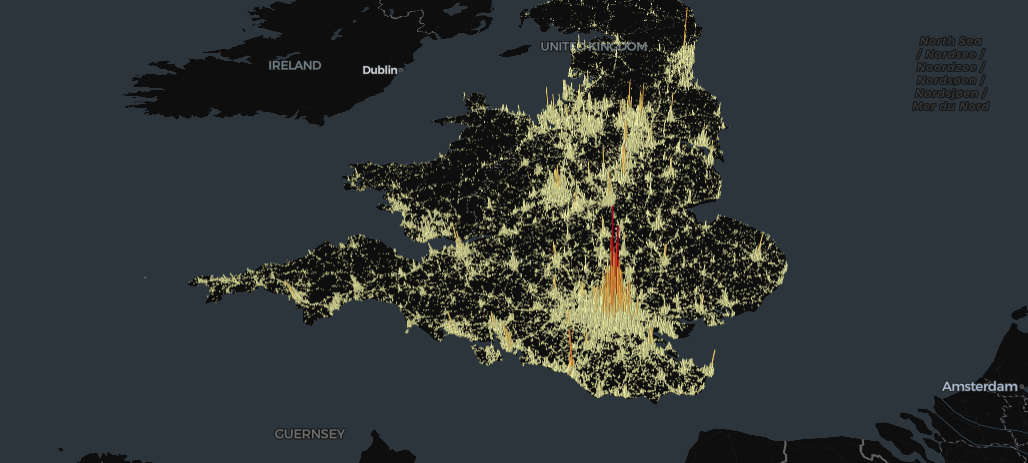

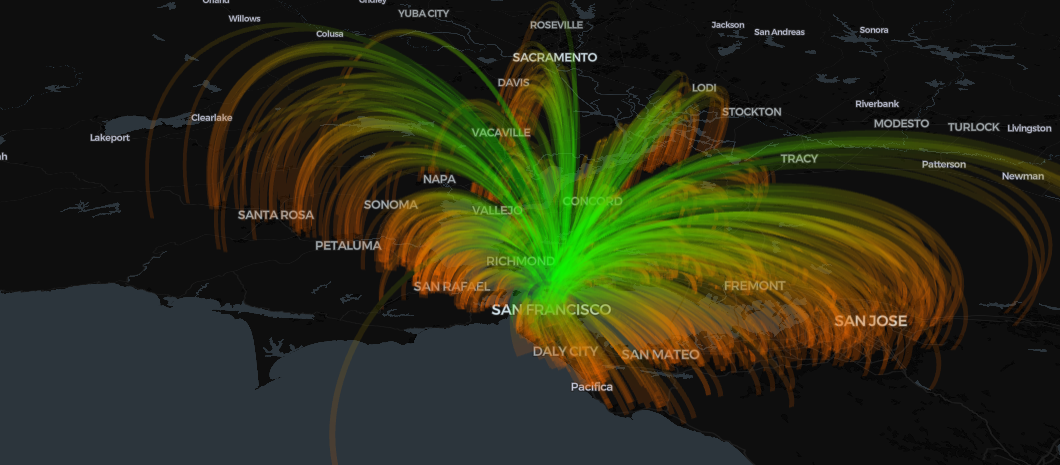

In [42]:
%pip install pydeck

Note: you may need to restart the kernel to use updated packages.


#### Folium과 Pydeck의 차이

Folium과 Pydeck은 모두 웹 기반 지도를 시각화할 수 있지만, **표현 방식과 활용 목적에서 분명한 차이**가 있다.

Folium은 Leaflet.js를 기반으로 한 라이브러리로, 행정경계, 포인트, 폴리곤, 라인 등을 지도 위에 올려  
**2차원 인터랙티브 지도**를 만드는 데 적합하다. 확대·축소, 이동, 레이어 토글, 툴팁·팝업 등 기본적인 사용자 상호작용이 잘 갖춰져 있으며,  
분석 결과를 직관적으로 설명하거나 웹 문서·보고서에 포함하기에 용이하다.

Pydeck은 deck.gl(WebGL)을 기반으로 한 라이브러리로, 대규모 공간 데이터를 GPU 가속을 통해 처리하며  
**3차원·고밀도 시각화**에 특화되어 있다. 높이(extrusion), 색상, 애니메이션, 시점(pitch·bearing)을 활용해  
공간 패턴과 규모 차이를 입체적으로 표현할 수 있다.

Folium은 지도 위에 “무엇이 어디에 있는지”를 명확하게 보여주는 데 강점이 있는 반면,  
Pydeck은 “얼마나 많고, 얼마나 강한가”와 같은  
**공간적 강도의 차이**를 시각적으로 강조하는 데 강점이 있다.

따라서 본 강의에서는 공간 구조와 커버리지를 이해하는 단계에서는 Folium을 사용하고,  

설치 시나리오별 효과와 인구 분포의 차이를 비교하는 단계에서는 Pydeck을 활용함으로써,  
각 도구의 역할을 분리해 사용하는 접근을 취한다.

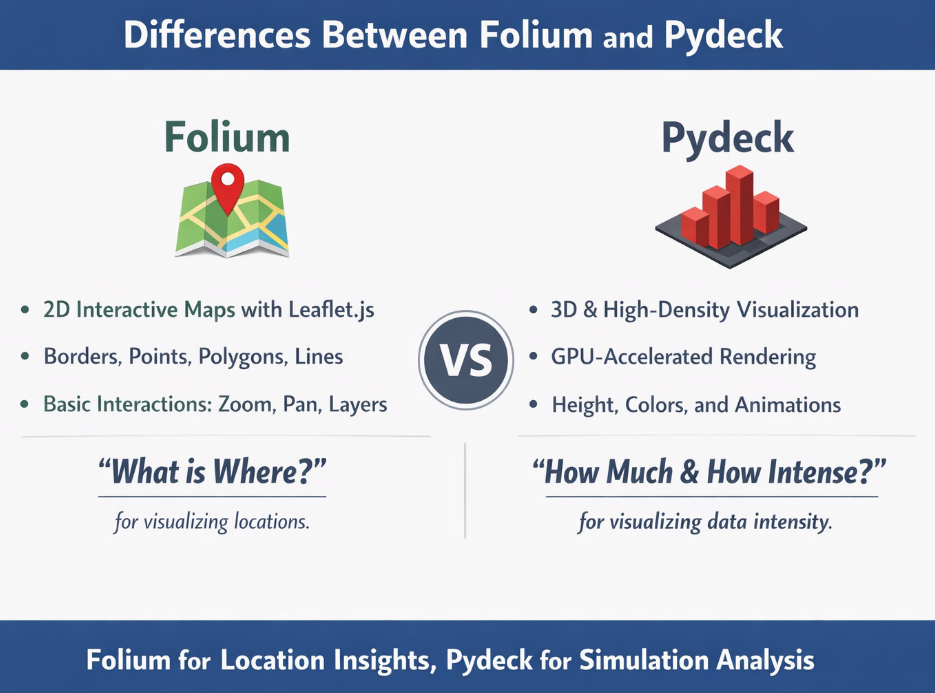

In [88]:
import os                     # 파일·폴더 경로 처리 (입출력 경로 관리)
import numpy as np            # 수치 연산 및 배열 처리
import pandas as pd           # 테이블 형태 데이터 처리 (DataFrame)
import geopandas as gpd       # 공간 데이터 처리 (GeoDataFrame)
from shapely.ops import unary_union  # 여러 지오메트리를 하나로 병합
import pydeck as pdk          # 대용량 공간 데이터를 위한 웹 기반 지도 시각화
from IPython.display import display  # Jupyter 환경에서 객체(DataFrame 등) 출력

In [89]:
GRID_SHP = "data/nlsp_021001001.shp"   # 인구 격자 쉐이프파일 경로

GRID_ID_COL = "gid"                   # 격자 고유 식별자 컬럼
GRID_POP_COL = "val"                   # 격자 인구 수 컬럼

gdf_grid = gpd.read_file(GRID_SHP)    # 격자 공간 데이터 불러오기
if gdf_grid.crs is None:              # 좌표계(CRS) 존재 여부 확인
    raise ValueError("GRID_SHP CRS None (.prj 확인)")  # 좌표계 없으면 오류 발생

In [90]:
gdf_grid = gdf_grid.to_crs(5179)   # 분석을 위해 좌표계를 EPSG:5179(중부원점)로 변환

In [91]:
gdf_grid["pop"] = pd.to_numeric(gdf_grid[GRID_POP_COL], errors="coerce") \
                    .fillna(0) \
                    .astype(float)   # 인구 컬럼을 숫자형으로 변환하고 결측치는 0으로 처리

In [ ]:
UNCOVERED_GPKG = "outputs/demo_uncovered.gpkg"   # 비커버(접근 불가) 지역 GPKG 경로

gdf_unc = gpd.read_file(UNCOVERED_GPKG)          # 비커버 지역 공간 데이터 로드
if gdf_unc.crs is None:                          # 좌표계 존재 여부 확인
    raise ValueError("UNCOVERED_GPKG CRS None")  # 좌표계 없으면 오류 발생

gdf_unc = gdf_unc.to_crs(5179)                   # 분석용 좌표계(EPSG:5179)로 변환

In [94]:
gdf_bus = gdf_bus.to_crs(5179)   # 버스 정류장 데이터를 분석용 좌표계(EPSG:5179)로 변환
gdf_sub = gdf_sub.to_crs(5179)   # 지하철역 데이터를 분석용 좌표계(EPSG:5179)로 변환

In [95]:
gdf_transit = gpd.GeoDataFrame(
    pd.concat([gdf_bus[["geometry"]], gdf_sub[["geometry"]]], ignore_index=True),  # 버스·지하철 위치 결합
    geometry="geometry",                                                           # geometry 컬럼 지정
    crs=5179                                                                       # 좌표계 설정(EPSG:5179)
)

In [96]:
gdf_grid_cent = gpd.GeoDataFrame(
    gdf_grid[[GRID_ID_COL, "pop"]].copy(),  # 격자 ID와 인구 컬럼만 복사
    geometry=gdf_grid.geometry.centroid,    # 각 격자의 중심점(centroid) 생성
    crs=5179                                # 좌표계 설정(EPSG:5179)
)

In [97]:
gdf_nn = gpd.sjoin_nearest(
    gdf_grid_cent[[GRID_ID_COL, "pop", "geometry"]].copy(),  # 격자 중심점(인구 포함)
    gdf_transit[["geometry"]].copy(),                        # 버스·지하철 위치
    how="inner",                                             # 최근접 대상만 매칭
    distance_col="dist_m"                                    # 최근접 거리(m) 저장
)

In [98]:
RADIUS_M = 1250.0 # 접근 가능 반경 기준(약 5분 이동 거리)

gdf_nn = gdf_nn[gdf_nn["dist_m"] <= RADIUS_M].copy() # 반경 이내 격자만 필터링

In [99]:
cand_ids = set(gdf_nn[GRID_ID_COL].astype(str))  # 조건을 만족한 후보 격자 ID를 집합으로 생성

In [100]:
gdf_cand = gdf_grid.loc[
    gdf_grid[GRID_ID_COL].astype(str).isin(cand_ids),  # 후보 격자 ID에 해당하는 행 선택
    [GRID_ID_COL, "pop", "geometry"]                   # 필요한 컬럼만 추출
].copy()                                               # 원본 보호를 위해 복사  

In [101]:
unc_union = unary_union(gdf_unc.geometry) # 비커버 지역 폴리곤을 하나로 병합

In [ ]:
# `intersects` is a yes/no test: a cell overlapping the uncovered area by 1 %
# is flagged exactly like one lying entirely inside it.
# `intersects`는 예/아니오 판정이다. 비커버 영역에 1%만 겹친 격자도
# 완전히 안에 있는 격자와 똑같이 표시된다.
#
# Measured on this dataset: binary counting overstates the uncovered
# population by +51.7% (8,672 vs 5,715). 22 cells overlap by under 10 % yet
# contribute 1,762 people at full weight.
# 이 데이터 기준 측정값: 이진 판정은 비커버 인구를 +51.7% 과대계상한다
# (8,672명 대 5,715명). 22개 격자는 10% 미만만 겹쳤는데 1,762명을 전액 기여한다.
#
# Keep the boolean for map styling, but use the FRACTION for any arithmetic.
# 지도 스타일링에는 불리언을 유지하되, 계산에는 '비율'을 사용한다.

gdf_cand["is_uncovered"] = gdf_cand.geometry.intersects(unc_union)
# 비커버 지역과의 교차 여부 (표시용 플래그)

gdf_cand["unc_frac"] = (
    gdf_cand.geometry.intersection(unc_union).area / gdf_cand.geometry.area
).clip(0, 1)
# 격자가 비커버 영역과 겹치는 면적 비율 (0~1, 계산용)


In [103]:
cand_gids = set(gdf_cand[GRID_ID_COL].astype(str)) # 최종 후보 격자 ID 집합 생성

In [104]:
sel_gid = "다사545408" # 분석할 격자 ID (이 값만 변경하여 재실행)

if str(sel_gid) not in cand_gids:  # 선택한 ID가 후보 목록에 없을 경우
    auto_gid = gdf_cand.sort_values("pop", ascending=False).iloc[0][GRID_ID_COL]  # 인구 최대 격자 자동 선택
    print(f"[WARN] sel_gid={sel_gid} 후보에 없음 → 자동선택 {auto_gid}")
    sel_gid = str(auto_gid)  # 선택 ID를 자동 선정된 격자로 대체

In [105]:
sel_poly = gdf_cand.loc[
    gdf_cand[GRID_ID_COL].astype(str) == sel_gid, 
    "geometry"
].iloc[0]  # 선택된 격자 ID에 해당하는 폴리곤 geometry 추출

In [106]:
sel_center = sel_poly.centroid  # 선택된 격자 폴리곤의 중심점 계산

In [107]:
circle_5179 = sel_center.buffer(RADIUS_M)  # 중심점 기준 반경 RADIUS_M(m) 원형 버퍼 생성

In [108]:
in_circle = gdf_cand.geometry.intersects(circle_5179)  # 반경 원 안에 포함되는 후보 격자 판별

In [ ]:
gdf_in = gdf_cand.loc[
    in_circle,
    [GRID_ID_COL, "pop", "is_uncovered", "unc_frac", "geometry"]
].copy()  # 반경 내에 포함된 후보 격자만 추출

# A cell only partly inside the radius should contribute only that part.
# Measured: full-weight counting overstates the population in radius by
# +23.1% (10,906 vs 8,861).
# 반경에 일부만 걸친 격자는 그 비율만큼만 기여해야 한다.
# 측정값: 전액 계상은 반경 내 인구를 +23.1% 과대계상한다 (10,906명 대 8,861명).
gdf_in["in_frac"] = (
    gdf_in.geometry.intersection(circle_5179).area / gdf_in.geometry.area
).clip(0, 1)

# Effective population = population x share of the cell inside the radius.
# 유효 인구 = 인구 x 반경 안에 들어온 격자 비율.
gdf_in["pop_eff"] = gdf_in["pop"] * gdf_in["in_frac"]


In [ ]:
# KPI 계산 (선택 반경 내 격자만 대상)
# Every figure below is area-weighted: a partial overlap contributes partially.
# 아래 모든 수치는 면적가중이다. 부분 중첩은 부분만 기여한다.

total_pop = float(gdf_in["pop_eff"].sum())                          # 반경 내 전체 인구
unc_pop   = float((gdf_in["pop_eff"] * gdf_in["unc_frac"]).sum())   # 비커버 지역 인구
cov_pop   = total_pop - unc_pop                                     # 커버된 인구
unc_rate  = (unc_pop / total_pop) if total_pop > 0 else 0.0         # 비커버 인구 비율

# The original unweighted figures, kept so the difference stays visible.
# 원본(비가중) 수치. 차이를 계속 보이게 하려고 함께 보존한다.
total_pop_raw = float(gdf_in["pop"].sum())
unc_pop_raw   = float(gdf_in.loc[gdf_in["is_uncovered"] == True, "pop"].sum())

# KPI 출력
print("\n======== KPI (area-weighted / 면적가중) ========")
print("selected gid:", sel_gid)                  # 선택된 격자 ID
print("cells in radius:", int(len(gdf_in)))      # 반경 내 격자 수
print(f"total_pop:      {total_pop:,.0f}   (unweighted {total_pop_raw:,.0f})")
print(f"uncovered_pop:  {unc_pop:,.0f}   (unweighted {unc_pop_raw:,.0f})")
print(f"covered_pop:    {cov_pop:,.0f}")
print(f"uncovered_rate: {unc_rate*100:.2f}%")
print("-- overstatement if unweighted / 비가중 시 과대계상 --")
print(f"  total:     +{total_pop_raw-total_pop:,.0f} "
      f"({100*(total_pop_raw-total_pop)/total_pop:+.1f}%)")
print(f"  uncovered: +{unc_pop_raw-unc_pop:,.0f} "
      f"({100*(unc_pop_raw-unc_pop)/unc_pop:+.1f}%)")
print("==============================================\n")


#### Mapbox
**Mapbox**는 웹·모바일 환경에서 지도를 제공하는 지도 플랫폼이다.  
다양한 지도 스타일과 타일 서비스를 API 형태로 제공하며,  
Pydeck·Folium 등과 연동해 인터랙티브 지도 시각화의 배경지도로 사용된다.

- Mapbox : https://www.mapbox.com/

In [121]:
# --- Basemap credentials -------------------------------------------------
# Never hard-code an API token in a notebook: it ships with the file, lands in
# git history, and gets baked into every exported HTML artifact.
# API 토큰을 노트북에 하드코딩하지 않는다. 파일과 함께 배포되고, git 이력에 남으며,
# 내보낸 HTML 결과물에도 그대로 구워진다.
#
# Set it in your shell before launching Jupyter:
# 주피터 실행 전에 셸에서 설정한다:
#   PowerShell : $env:MAPBOX_API_KEY = "pk...."
#   bash       : export MAPBOX_API_KEY="pk...."
#
# NOTE: lecture 4 migrates to MapLibre + PMTiles, which needs no token at all.
# 참고: 4강은 토큰이 전혀 필요 없는 MapLibre + PMTiles로 이전한다.

MAPBOX_API_KEY = os.environ.get("MAPBOX_API_KEY", "")

if not MAPBOX_API_KEY:
    print("[WARN] MAPBOX_API_KEY is not set - the basemap will not render.")
    print("[경고] MAPBOX_API_KEY 미설정 - 베이스맵이 렌더링되지 않습니다.")

os.environ["MAPBOX_API_KEY"] = MAPBOX_API_KEY

# Basemap style. Comment/uncomment to switch.
# 베이스맵 스타일. 주석을 바꿔가며 전환한다.
MAP_STYLE = "mapbox://styles/mapbox/dark-v11"                 # dark / 다크
# MAP_STYLE = "mapbox://styles/mapbox/light-v11"              # light / 라이트
# MAP_STYLE = "mapbox://styles/mapbox/satellite-streets-v12"  # satellite / 위성


In [122]:
gdf_ll = gdf_in.to_crs(4326).copy()  # 시각화를 위해 좌표계를 WGS84(EPSG:4326)로 변환

In [123]:
pop = gdf_ll["pop"].clip(lower=0).astype(float) # 인구값 음수 방지 및 실수형 변환
cap_val = float(pop.quantile(0.995)) if 0.995 < 1.0 else float(pop.max()) # 상위 outlier 컷 기준값
pop_capped = np.minimum(pop, cap_val) # 상한값 초과 인구 컷
gdf_ll["elev"] = (np.power(pop_capped, 1.80) * 0.02).astype(float) # 인구 기반 높이(elevation) 계산

In [124]:
p_red = float(np.quantile(pop_capped, 0.95))  # 상위 강조(빨강) 기준 인구값
p80   = float(np.quantile(pop_capped, 0.80))       # 상위 20% 기준 인구값
p50   = float(np.quantile(pop_capped, 0.50))       # 중위수(50%) 기준 인구값
p20   = float(np.quantile(pop_capped, 0.20))       # 하위 20% 기준 인구값

#### 꼭 알아야 할 pydeck 핵심 함수·개념 정리

##### 1. pdk.Layer
pydeck에서 시각화의 가장 핵심 단위는 `Layer`이다.  
지도 위에 **무엇을, 어떤 방식으로 그릴 것인지**를 정의하는 객체이며,  
PolygonLayer, ScatterplotLayer, LineLayer 등 다양한 타입이 존재한다.

pydeck은 **Layer(무엇을 그릴지) → ViewState(어떻게 볼지) → Deck(지도 완성)**  
이라는 구조로 이해하면 된다.

##### 2. PolygonLayer : `PolygonLayer`는 폴리곤 데이터를 지도 위에 표현하는 레이어이다.
- `get_polygon` : 폴리곤 좌표 필드 지정
- `extruded=True` : elevation 값을 이용한 3D 표현 활성화
- `get_elevation` : 폴리곤 높이 값
- `get_fill_color` : 폴리곤 색상
- `pickable=True` : 마우스 인터랙션(툴팁) 활성화

##### 3. pdk.ViewState : `ViewState`는 지도의 **카메라 위치와 시점**을 결정한다.
- `latitude`, `longitude` : 지도 중심 좌표
- `zoom` : 확대 수준
- `pitch` : 기울기(3D 효과의 핵심)
- `bearing` : 회전 각도

##### 4. pdk.Deck : `Deck`은 모든 레이어와 뷰 설정을 하나로 묶는 **최종 지도 객체**이다.
- 여러 Layer를 동시에 관리
- 지도 스타일(Mapbox) 지정
- 툴팁 설정 가능

##### 5. deck.to_html() : `to_html()`은 pydeck 지도를 **독립 실행 가능한 HTML 파일**로 저장한다.
- Jupyter, VS Code, Colab 환경과 무관하게 실행 가능
- 정책 보고서·공유용 결과물로 바로 활용 가능

In [125]:
# 인구 규모에 따른 색상 지정 (연노랑 → 주황 → 상위 0.95만 빨강)
fill_colors = []
for p, is_unc in zip(pop_capped, gdf_ll["is_uncovered"]):
    if p <= p20:
        c = [255, 248, 210, 120]   # 하위 인구: 매우 연한 노랑
    elif p <= p50:
        c = [255, 232, 160, 140]   # 중하위: 연한 노랑-주황
    elif p <= p80:
        c = [255, 200, 120, 165]   # 중상위: 주황
    elif p <= p_red:
        c = [245, 150,  95, 190]   # 상위: 진한 주황
    else:
        c = [210,  70,  60, 220]   # 최상위: 빨강

    # 비커버는 더 진하게, 커버는 투명도 낮춤
    if bool(is_unc):
        c[3] = min(255, c[3] + 25)  # 비커버: alpha 증가
    else:
        c[3] = max(60,  c[3] - 35)  # 커버: alpha 감소

    fill_colors.append(c)

gdf_ll["fill_color"] = fill_colors  # 계산된 색상 컬럼 추가

In [126]:
# PolygonLayer 입력용 좌표 생성 (Polygon / MultiPolygon 모두 처리)
records = []
for gid, popv, is_unc, elev, geom, fc in zip(
    gdf_ll[GRID_ID_COL].astype(str).tolist(),   # 격자 ID
    gdf_ll["pop"].tolist(),                     # 인구 값
    gdf_ll["is_uncovered"].tolist(),            # 비커버 여부
    gdf_ll["elev"].tolist(),                    # 높이 값
    gdf_ll.geometry.tolist(),                   # 격자 geometry
    gdf_ll["fill_color"].tolist()               # 채우기 색상
):
    if geom is None or geom.is_empty:
        continue                                # 빈 geometry 제외

    if geom.geom_type == "Polygon":
        polys = [geom]                          # 단일 폴리곤
    elif geom.geom_type == "MultiPolygon":
        polys = list(geom.geoms)                # 멀티 폴리곤 분해
    else:
        continue                                # 기타 geometry 제외

    for poly in polys:
        records.append({
            "gid": gid,                         # 격자 ID
            "pop": float(popv),                 # 인구 값
            "is_uncovered": bool(is_unc),       # 비커버 여부
            "elev": float(elev),                # extrusion 높이
            "fill_color": fc,                   # 폴리곤 색상
            "polygon": list(poly.exterior.coords)  # PolygonLayer용 좌표
        })

#### pydeck 좌표계 사용 원칙 (EPSG:4326)

**pydeck은 시각화 단계에서 반드시 EPSG:4326(WGS84, 경·위도 좌표계)** 를 사용해야 한다.
이는 pydeck이 내부적으로 Mapbox(deck.gl → WebGL)를 기반으로 동작하며,  
Mapbox가 위도(latitude)·경도(longitude) 좌표계를 전제로 지도를 렌더링하기 때문이다.

##### 권장 좌표계 흐름

1. **분석 단계 (GeoPandas · Shapely)**
   - EPSG:5179, 5181 등 **미터 단위 투영 좌표계 사용**
   - 거리 계산, 버퍼, 최근접 조인 등 정확한 공간 연산 수행

2. **시각화 단계 (pydeck)**
   - `to_crs(4326)`으로 변환
   - `PolygonLayer`, `ScatterplotLayer` 등에 전달

In [127]:
# 선택 반경을 표시할 링(원형 라인) 생성
circle_ll = gpd.GeoSeries([circle_5179], crs=5179).to_crs(4326).iloc[0] # 반경 원을 WGS84로 변환
circle_coords = list(circle_ll.exterior.coords) # 라인용 좌표 추출

In [128]:
# 인구 격자 3D 폴리곤 레이어 생성
layer_blocks = pdk.Layer(
    "PolygonLayer",           # 폴리곤 기반 3D 레이어
    data=records,             # 폴리곤 좌표 및 속성 데이터
    get_polygon="polygon",    # 폴리곤 좌표 필드
    extruded=True,            # 높이값(elevation)으로 3D 표현
    filled=True,              # 내부 채우기
    stroked=False,            # 외곽선 비활성화
    wireframe=False,          # 와이어프레임 비활성화
    get_elevation="elev",     # 폴리곤 높이 값
    elevation_scale=1,        # 높이 스케일 계수
    get_fill_color="fill_color",  # 폴리곤 색상
    pickable=True,            # 마우스 인터랙션 활성화
)

In [129]:
# 반경을 표시하는 원형 링 레이어 생성
layer_circle = pdk.Layer(
    "PolygonLayer",                 # 폴리곤 레이어 사용
    data=[{"polygon": circle_coords}],  # 반경 원 좌표
    get_polygon="polygon",          # 폴리곤 좌표 필드
    filled=False,                   # 내부 채우기 비활성화
    stroked=True,                   # 외곽선만 표시
    get_line_color=[255, 255, 255, 220],  # 링 색상(흰색)
    get_line_width=120,           # 링 두께
)

In [133]:
# 카메라 뷰 설정 (선택 격자 중심 기준)
sel_center_ll = gpd.GeoSeries([sel_center], crs=5179).to_crs(4326).iloc[0]  # 중심점 WGS84 변환

view = pdk.ViewState(
    latitude=float(sel_center_ll.y),    # 지도 중심 위도
    longitude=float(sel_center_ll.x),   # 지도 중심 경도
    zoom=13.9,                          # 줌 레벨
    pitch=70,                           # 기울기(3D 효과)
    bearing=30                          # 회전 각도
)

# pydeck 지도 객체 생성
deck = pdk.Deck(
    layers=[layer_blocks, layer_circle],  # 인구 블록 + 반경 링 레이어
    initial_view_state=view,               # 초기 뷰 상태
    map_provider="mapbox",                 # 지도 제공자
    map_style=MAP_STYLE,                   # 지도 스타일
    tooltip={                              # 마우스 오버 툴팁
        "text": "gid: {gid}\npop: {pop}\nuncovered: {is_uncovered}\nelev: {elev}"
    }
)

# HTML 파일로 저장 및 브라우저에서 열기
deck.to_html(
    "deck_3d_population_yellow_orange_red_radius_only.html",
    open_browser=True,
    notebook_display=False
)

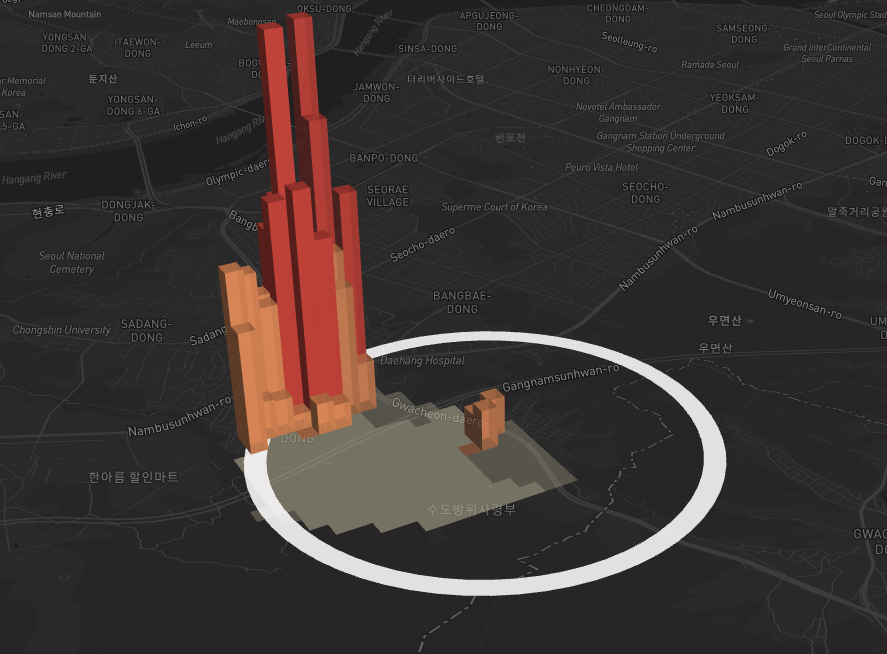